# Analyse exploratoire — Seattle Building Energy Benchmarking 2016

Portage de la partie *Analyse exploratoire* du notebook P3
(`Lebayle_Kevin_1_EDA&FE_02.01.26.ipynb`), rejouée sur les données brutes
`data/2016.csv`.

**Périmètre :** nettoyage et exploration uniquement. Le feature engineering est
traité à part (`src/features.py`), pour être partagé entre l'entraînement et
l'application.

**Sortie :** `data/dfclean.csv` — 21 colonnes, une ligne par bâtiment non
résidentiel, cibles `SiteEnergyUse(kBtu)` et `TotalGHGEmissions`.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import seaborn as sns
from pathlib import Path

# Resolve the project root whether the notebook runs from notebooks/ or from the repo root
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data"

pd.set_option("display.max_columns", 50)

In [ ]:
dini = pd.read_csv(DATA_DIR / "2016.csv")
dini

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,7,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,88434,0,88434,Hotel,Hotel,88434.0,NaN,NaN,NaN,NaN,NaN,60.0,81.699997,84.300003,182.500000,189.000000,7.226362e+06,7.456910e+06,2003882.00,1.156514e+06,3.946027e+06,12764.529300,1.276453e+06,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,7,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880.0,Parking,15064.0,Restaurant,4622.0,NaN,61.0,94.800003,97.900002,176.100006,179.399994,8.387933e+06,8.664479e+06,0.00,9.504252e+05,3.242851e+06,51450.816410,5.145082e+06,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,7,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,956110,196718,759392,Hotel,Hotel,756493.0,NaN,NaN,NaN,NaN,NaN,43.0,96.000000,97.699997,241.899994,244.100006,7.258702e+07,7.393711e+07,21566554.00,1.451544e+07,4.952666e+07,14938.000000,1.493800e+06,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,7,DOWNTOWN,47.61412,-122.33664,1926,1.0,10,61320,0,61320,Hotel,Hotel,61320.0,NaN,NaN,NaN,NaN,NaN,56.0,110.800003,113.300003,216.199997,224.000000,6.794584e+06,6.946800e+06,2214446.25,8.115253e+05,2.768924e+06,18112.130860,1.811213e+06,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,123445.0,Parking,68009.0,Swimming Pool,0.0,NaN,75.0,114.800003,118.699997,211.399994,215.600006,1.417261e+07,1.465650e+07,0.00,1.573449e+06,5.368607e+06,88039.984380,8.803998e+06,False,NaN,Compliant,NaN,505.01,2.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3371,50222,2016,Nonresidential COS,Office,Horticulture building,1600 S Dakota St,Seattle,WA,NaN,1624049080,2,GREATER DUWAMISH,47.56722,-122.31154,1990,1.0,1,12294,0,12294,Office,Office,12294.0,NaN,NaN,NaN,NaN,NaN,46.0,69.099998,76.699997,161.699997,176.100006,8.497457e+05,9.430032e+05,0.00,1.536550e+05,5.242709e+05,3254.750244,3.254750e+05,True,NaN,Error - Correct Default Data,NaN,20.94,1.70
3372,50223,2016,Nonresidential COS,Other,International district/Chinatown CC,719 8th Ave S,Seattle,WA,NaN,3558300000,2,DOWNTOWN,47.59625,-122.32283,2004,1.0,1,16000,0,16000,Other - Recreation,Other - Recreation,16000.0,NaN,NaN,NaN,NaN,NaN,NaN,59.400002,65.900002,114.199997,118.900002,9.502762e+05,1.053706e+06,0.00,1.162210e+05,3.965461e+05,5537.299805,5.537300e+05,False,NaN,Compliant,NaN,32.17,2.01
3373,50224,2016,Nonresidential COS,Other,Queen Anne Pool,1920 1st Ave W,Seattle,WA,NaN,1794501150,7,MAGNOLIA / QUEEN ANNE,47.63644,-122.35784,1974,1.0,1,13157,0,13157,"Fitness Center/Health Club/Gym, Other - Recrea...",Other - Recreation,7583.0,Fitness Center/Health Club/Gym,5574.0,Swimmin

## Nettoyage des données

### Filtre sur Non-Residentiel

In [ ]:
# type de buildings

dini.groupby(["BuildingType"]).size()

BuildingType
Campus                    24
Multifamily HR (10+)     110
Multifamily LR (1-4)    1018
Multifamily MR (5-9)     580
NonResidential          1460
Nonresidential COS        85
Nonresidential WA          1
SPS-District K-12         98
dtype: int64

In [ ]:
# on enleve tout ce qui est residentiel.

df = dini[~dini["BuildingType"].str.startswith("Multifamily", na=False)].copy()
df

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,7,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,88434,0,88434,Hotel,Hotel,88434.0,NaN,NaN,NaN,NaN,NaN,60.0,81.699997,84.300003,182.500000,189.000000,7.226362e+06,7.456910e+06,2003882.00,1.156514e+06,3.946027e+06,12764.529300,1.276453e+06,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,7,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880.0,Parking,15064.0,Restaurant,4622.0,NaN,61.0,94.800003,97.900002,176.100006,179.399994,8.387933e+06,8.664479e+06,0.00,9.504252e+05,3.242851e+06,51450.816410,5.145082e+06,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,7,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,956110,196718,759392,Hotel,Hotel,756493.0,NaN,NaN,NaN,NaN,NaN,43.0,96.000000,97.699997,241.899994,244.100006,7.258702e+07,7.393711e+07,21566554.00,1.451544e+07,4.952666e+07,14938.000000,1.493800e+06,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,7,DOWNTOWN,47.61412,-122.33664,1926,1.0,10,61320,0,61320,Hotel,Hotel,61320.0,NaN,NaN,NaN,NaN,NaN,56.0,110.800003,113.300003,216.199997,224.000000,6.794584e+06,6.946800e+06,2214446.25,8.115253e+05,2.768924e+06,18112.130860,1.811213e+06,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,123445.0,Parking,68009.0,Swimming Pool,0.0,NaN,75.0,114.800003,118.699997,211.399994,215.600006,1.417261e+07,1.465650e+07,0.00,1.573449e+06,5.368607e+06,88039.984380,8.803998e+06,False,NaN,Compliant,NaN,505.01,2.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3371,50222,2016,Nonresidential COS,Office,Horticulture building,1600 S Dakota St,Seattle,WA,NaN,1624049080,2,GREATER DUWAMISH,47.56722,-122.31154,1990,1.0,1,12294,0,12294,Office,Office,12294.0,NaN,NaN,NaN,NaN,NaN,46.0,69.099998,76.699997,161.699997,176.100006,8.497457e+05,9.430032e+05,0.00,1.536550e+05,5.242709e+05,3254.750244,3.254750e+05,True,NaN,Error - Correct Default Data,NaN,20.94,1.70
3372,50223,2016,Nonresidential COS,Other,International district/Chinatown CC,719 8th Ave S,Seattle,WA,NaN,3558300000,2,DOWNTOWN,47.59625,-122.32283,2004,1.0,1,16000,0,16000,Other - Recreation,Other - Recreation,16000.0,NaN,NaN,NaN,NaN,NaN,NaN,59.400002,65.900002,114.199997,118.900002,9.502762e+05,1.053706e+06,0.00,1.162210e+05,3.965461e+05,5537.299805,5.537300e+05,False,NaN,Compliant,NaN,32.17,2.01
3373,50224,2016,Nonresidential COS,Other,Queen Anne Pool,1920 1st Ave W,Seattle,WA,NaN,1794501150,7,MAGNOLIA / QUEEN ANNE,47.63644,-122.35784,1974,1.0,1,13157,0,13157,"Fitness Center/Health Club/Gym, Other - Recrea...",Other - Recreation,7583.0,Fitness Center/Health Club/Gym,5574.0,Swimmin

In [ ]:
# verification : 3 Low Rise Multifamily sont encore presents en primary property type
df.groupby(["BuildingType", "PrimaryPropertyType"]).size()

BuildingType        PrimaryPropertyType        
Campus              K-12 School                      4
                    Large Office                     1
                    Low-Rise Multifamily             1
                    Mixed Use Property               4
                    Other                            7
                    Restaurant                       1
                    University                       6
NonResidential      Distribution Center             51
                    Hospital                        10
                    Hotel                           76
                    K-12 School                     39
                    Laboratory                      10
                    Large Office                   168
                    Low-Rise Multifamily             2
                    Medical Office                  38
                    Mixed Use Property             102
                    Other                          185
                 

In [ ]:
# Retrait de ces 3 batiments residentiels

i = df[(df.PrimaryPropertyType == "Low-Rise Multifamily")].index
df = df.drop(i)

In [ ]:
# On va garder uniquement les colonnes avec des variables exploitables --> 23 colonnes
# Variables cibles : 'SiteEnergyUse(kBtu)'   et   'TotalGHGEmissions'

relevant = [
    "OSEBuildingID",
    "PrimaryPropertyType",
    "Neighborhood",
    "YearBuilt",
    "NumberofBuildings",
    "NumberofFloors",
    "PropertyGFATotal",
    "PropertyGFAParking",
    "PropertyGFABuilding(s)",
    "ListOfAllPropertyUseTypes",
    "LargestPropertyUseType",
    "LargestPropertyUseTypeGFA",
    "SecondLargestPropertyUseType",
    "SecondLargestPropertyUseTypeGFA",
    "ThirdLargestPropertyUseType",
    "ThirdLargestPropertyUseTypeGFA",
    "SiteEnergyUse(kBtu)",
    "SteamUse(kBtu)",
    "Electricity(kBtu)",
    "NaturalGas(kBtu)",
    "TotalGHGEmissions",
    # Qualite de donnee declaree par la Ville : conservees comme metadonnees,
    # jamais comme features.  --> ecart E16
    "Outlier",
    "ComplianceStatus",
]


df = df[relevant].reset_index(drop=True)
df

### Overview des manquants et cibles = 0

<Axes: >

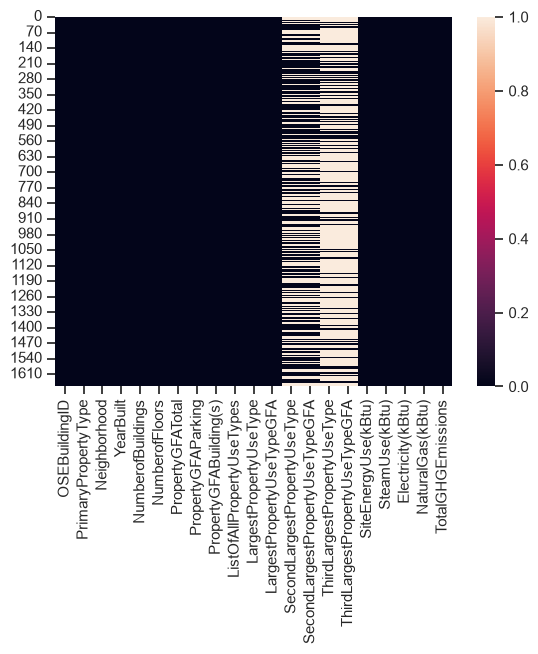

In [ ]:
dna = df.isna()
sns.heatmap(data=dna)

In [ ]:
print(df["SiteEnergyUse(kBtu)"].describe())
print(df["SiteEnergyUse(kBtu)"].info())

print(df["TotalGHGEmissions"].describe())
print(df["TotalGHGEmissions"].info())

count    1.663000e+03
mean     8.449617e+06
std      3.026977e+07
min      0.000000e+00
25%      1.230468e+06
50%      2.556131e+06
75%      6.917379e+06
max      8.739237e+08
Name: SiteEnergyUse(kBtu), dtype: float64
<class 'pandas.Series'>
RangeIndex: 1665 entries, 0 to 1664
Series name: SiteEnergyUse(kBtu)
Non-Null Count  Dtype  
--------------  -----  
1663 non-null   float64
dtypes: float64(1)
memory usage: 13.1 KB
None
count     1663.000000
mean       185.272616
std        752.621187
min         -0.800000
25%         20.005000
50%         49.620000
75%        142.865000
max      16870.980000
Name: TotalGHGEmissions, dtype: float64
<class 'pandas.Series'>
RangeIndex: 1665 entries, 0 to 1664
Series name: TotalGHGEmissions
Non-Null Count  Dtype  
--------------  -----  
1663 non-null   float64
dtypes: float64(1)
memory usage: 13.1 KB
None


In [ ]:
# 2 lignes n'ont pas de valeurs pour SiteEnergyUse, on les supprime (ce sont les memes pour emissions)
df = df.dropna(subset=["SiteEnergyUse(kBtu)"])
df.shape[0]

1663

In [ ]:
# 6 lignes ont valeur=0 pour TotalGHGEmissions, on les supprime
df = df[df["TotalGHGEmissions"] != 0]
df.shape[0]

1657

In [ ]:
# Les lignes suivantes ont une valeur de 0 pour SiteEnergyUse(kBtu) MAIS on peut la recalculer via la somme de Steam + Natural + Electricity
df.loc[df["SiteEnergyUse(kBtu)"] == 0, :]

,OSEBuildingID,PrimaryPropertyType,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,SiteEnergyUse(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions
30,37,K-12 School,MAGNOLIA / QUEEN ANNE,1989,1.0,2,51582,0,51582,K-12 School,K-12 School,55166.0,NaN,NaN,NaN,NaN,0.0,0.0,1496816.0,0.0,10.43
61,87,K-12 School,SOUTHWEST,1948,1.0,2,53352,0,53352,K-12 School,K-12 School,65568.0,NaN,NaN,NaN,NaN,0.0,0.0,600813.0,0.0,4.19
80,118,K-12 School,DELRIDGE,1999,1.0,3,74468,0,74468,K-12 School,K-12 School,75364.0,NaN,NaN,NaN,NaN,0.0,0.0,1698176.0,0.0,11.84
84,122,K-12 School,SOUTHEAST,1991,1.0,2,58933,0,58933,K-12 School,K-12 School,60725.0,NaN,NaN,NaN,NaN,0.0,0.0,2347138.0,0.0,16.36
94,140,K-12 School,LAKE UNION,1991,1.0,3,66588,0,66588,K-12 School,K-12 School,66588.0,NaN,NaN,NaN,NaN,0.0,0.0,2104286.0,0.0,14.67
132,217,K-12 School,BALLARD,1959,1.0,1,160270,0,160270,K-12 School,K-12 School,160270.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,4318917.0,229.38
138,227,K-12 School,CENTRAL,1963,1.0,3,136188,0,136188,K-12 School,K-12 School,136188.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,3217877.0,170.90
604,820,K-12 School,CENTRAL,1988,1.0,1,52924,0,52924,K-12 School,K-12 School,52924.0,NaN,NaN,NaN,NaN,0.0,0.0,1957268.0,0.0,13.64
620,850,K-12 School,CENTRAL,1988,1.0,3,55353,0,55353,K-12 School,K-12 School,55353.0,NaN,NaN,NaN,NaN,0.0,0.0,1433596.0,0.0,9.99
1109,23722,K-12 School,BALLARD,1958,1.0,1,39971,0,39971,K-12 School,K-12 School,40867.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,945537.0,50.22


In [ ]:
# recalcul
df.loc[df["SiteEnergyUse(kBtu)"] == 0, "SiteEnergyUse(kBtu)"] = (
    df.loc[df["SiteEnergyUse(kBtu)"] == 0, "SteamUse(kBtu)"].values
    + df.loc[df["SiteEnergyUse(kBtu)"] == 0, "Electricity(kBtu)"].values
    + df.loc[df["SiteEnergyUse(kBtu)"] == 0, "NaturalGas(kBtu)"].values
)

## Observations issues de `describe()` et `info()`

Plusieurs points de nettoyage identifiés :

* **Number of Buildings** : Les valeurs à `0` ainsi que les `NaN` doivent être ramenées à `1` (valeur proche de la moyenne).
* **Number of Floors** : Le minimum actuel est de `0`. Il est nécessaire de le corriger à `4` (valeur proche de la moyenne).
* **Anomalies de consommation** :
    * **Electricity (kBtu)** : Présence de valeurs négatives à corriger.
    * **Total GHG Emissions** : Présence de valeurs négatives à corriger.
* **Données manquantes** : Les colonnes `LargestPropertyUseType` et `LargestPropertyUseTypeGFA` présentent **4 valeurs manquantes** à traiter.

In [ ]:
df.describe()

,OSEBuildingID,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseTypeGFA,SiteEnergyUse(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions
count,1657.000000,1657.000000,1657.000000,1657.000000,1.657000e+03,1657.000000,1.657000e+03,1.653000e+03,851.000000,351.000000,1.657000e+03,1.657000e+03,1.657000e+03,1.657000e+03,1657.000000
mean,16362.292094,1961.901026,1.169584,4.131563,1.184469e+05,12961.820157,1.054851e+05,9.839403e+04,36127.676025,14982.052418,8.487810e+06,5.153566e+05,5.871892e+06,1.981338e+06,185.943488
std,13847.794093,32.735285,2.939337,6.582683,2.966331e+05,42398.960103,2.833365e+05,2.764001e+05,66345.350393,36887.131567,3.031734e+07,5.528777e+06,2.084938e+07,9.395156e+06,753.900621
min,1.000000,1900.000000,0.000000,0.000000,1.128500e+04,0.000000,3.636000e+03,5.656000e+03,0.000000,0.000000,1.680890e+04,0.000000e+00,-1.154170e+05,0.000000e+00,-0.800000
25%,583.000000,1930.000000,1.000000,1.000000,2.940000e+04,0.000000,2.839700e+04,2.552100e+04,5290.000000,2649.000000,1.257775e+06,0.000000e+00,7.252430e+05,0.000000e+00,20.180000
50%,21150.000000,1965.000000,1.000000,2.000000,4.928000e+04,0.000000,4.736800e+04,4.381300e+04,12000.000000,6000.000000,2.582687e+06,0.000000e+00,1.618916e+06,5.040570e+05,49.790000
75%,24603.000000,1989.000000,1.000000,4.000000,1.060000e+05,0.000000,9.490000e+04,9.200000e+04,31881.000000,12990.000000,6.917478e+06,0.000000e+00,4.878886e+06,1.528541e+06,144.410000
max,50226.000000,2015.000000,111.000000,99.000000,9.320156e+06,512608.000000,9.320156e+06,9.320156e+06,639931.000000,459748.000000,8.739237e+08,1.349435e+08,6.570744e+08,2.979090e+08,16870.980000


In [ ]:
df.info()

<class 'pandas.DataFrame'>
Index: 1657 entries, 0 to 1664
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    1657 non-null   int64  
 1   PrimaryPropertyType              1657 non-null   str    
 2   Neighborhood                     1657 non-null   str    
 3   YearBuilt                        1657 non-null   int64  
 4   NumberofBuildings                1657 non-null   float64
 5   NumberofFloors                   1657 non-null   int64  
 6   PropertyGFATotal                 1657 non-null   int64  
 7   PropertyGFAParking               1657 non-null   int64  
 8   PropertyGFABuilding(s)           1657 non-null   int64  
 9   ListOfAllPropertyUseTypes        1657 non-null   str    
 10  LargestPropertyUseType           1653 non-null   str    
 11  LargestPropertyUseTypeGFA        1653 non-null   float64
 12  SecondLargestPropertyUseType     851

In [ ]:
# Number of buildings -> on ramene les 0 a 1.
# Verifie dans les donnees : aucun de ces 52 batiments n'est de type "Campus", et leur GFA mediane
# (55 561 sq ft) est proche de celle des mono-batiments (48 020) et tres loin des multi-batiments
# (111 445). L'hypothese "champ laisse a 0 parce qu'il n'y a qu'un seul batiment" est la plus probable.
print("de 0 a 1 : ", df.loc[df["NumberofBuildings"] == 0, :].shape[0])

df.loc[df["NumberofBuildings"] == 0, ["NumberofBuildings"]] = 1

de 0 a 1 :  52


In [ ]:
# Number of Floors -> les 0 sont remplaces par la mediane des valeurs non nulles, calculee et non
# codee en dur. P3 utilisait la constante 4, justifiee par "proche de la moyenne". Mais la
# distribution est tres asymetrique (moyenne 4.17, mediane 2) : sur ce type de variable la mediane
# est l'imputation adaptee.  --> ecart E02
floors_median = df.loc[df["NumberofFloors"] > 0, "NumberofFloors"].median()
print(f"de 0 a {floors_median:.0f} : ", df.loc[df["NumberofFloors"] == 0, :].shape[0])

df.loc[df["NumberofFloors"] == 0, ["NumberofFloors"]] = floors_median

de 0 a 2 :  16


In [ ]:
# Electricity kBtu et totalEMissions : Une seule valeur negative, un building avec un toit de panneaux solaires...
# https://en.wikipedia.org/wiki/Bullitt_Center
# Suppression de cette ligne comme elle est toute seule dans ce cas. Aurait pu etre utilisée pour la target totalenergyuse neanmoins.
print(df.loc[df["Electricity(kBtu)"] < 0, :].shape[0])
df = df.drop(df[df["OSEBuildingID"] == 49784].index)

1


In [ ]:
# LargestPropertyUseType and GFA

# Pour trois d'entre eux, un seul property type dans ListOfAllPropertyUseTypes : on peut recopier
# le PrimaryPropertyType et le PropertyGFATotal de la ligne elle-meme.
# Pour le batiment 496, il nous manque la repartition. C'est un element assez critique, mais comme
# cela ne concerne qu'une ligne sur 1656 on la garde : les modeles devraient gerer la valeur manquante.

df.loc[df["LargestPropertyUseType"].isna(), :]

,OSEBuildingID,PrimaryPropertyType,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,SiteEnergyUse(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions
347,496,Self-Storage Facility,BALLARD,1946,2.0,2,111445,0,111445,"Fitness Center/Health Club/Gym, Office, Other ...",NaN,NaN,NaN,NaN,NaN,NaN,5.697472e+06,0.0,3007514.0,2689958.0,163.83
820,21103,Hotel,DOWNTOWN,1910,1.0,8,61721,0,61721,Hotel,NaN,NaN,NaN,NaN,NaN,NaN,2.897080e+06,0.0,2534592.0,362488.0,36.92
1348,25568,Small- and Mid-Sized Office,LAKE UNION,2008,1.0,4,48350,0,48350,Office,NaN,NaN,NaN,NaN,NaN,NaN,3.168131e+06,0.0,3168131.0,0.0,22.09
1365,25711,Restaurant,DOWNTOWN,1913,1.0,3,28800,0,28800,Restaurant,NaN,NaN,NaN,NaN,NaN,NaN,8.999242e+05,0.0,402907.0,497017.0,29.21


> **Écart avec P3 — `E01`**
>
> Le notebook d'origine recopiait les valeurs du bâtiment `21103` (Hotel,
> 61 721 sq ft) pour les trois bâtiments, au lieu des leurs. La cellule
> ci-dessous corrige ce comportement : chaque bâtiment reçoit son propre
> `PrimaryPropertyType` et son propre `PropertyGFATotal`.
>
> Voir `docs/ecarts_vs_P3.md`.

In [ ]:
# Correction manuelle des trois batiments dont ListOfAllPropertyUseTypes ne contient qu'un seul
# usage : on recopie le PrimaryPropertyType et le PropertyGFATotal de la ligne elle-meme.
# P3 recopiait les valeurs du batiment 21103 pour les trois (erreur de copier-coller).  --> ecart E01
for building_id in (21103, 25568, 25711):
    row = df["OSEBuildingID"] == building_id
    df.loc[row, "LargestPropertyUseType"] = df.loc[row, "PrimaryPropertyType"].values
    df.loc[row, "LargestPropertyUseTypeGFA"] = df.loc[row, "PropertyGFATotal"].values

### Normalisation des quartiers

`Neighborhood` compte 19 modalités brutes pour **13 quartiers réels** : la casse
n'est pas uniforme (`BALLARD` / `Ballard`) et un libellé porte un suffixe
(`DELRIDGE NEIGHBORHOODS`). 29 bâtiments se retrouvent ainsi dans des catégories
fantômes de 1 à 9 individus, coupés de leur quartier d'origine.

Écart avec P3, qui encodait les 19 modalités telles quelles — voir `docs/ecarts_vs_P3.md` (E07).

In [ ]:
# Uniformisation de la casse et retrait du suffixe "NEIGHBORHOODS".  --> ecart E07
avant = df["Neighborhood"].nunique()
df["Neighborhood"] = (
    df["Neighborhood"].str.upper().str.replace(" NEIGHBORHOODS", "", regex=False).str.strip()
)
print(f"quartiers : {avant} -> {df['Neighborhood'].nunique()}")
df["Neighborhood"].value_counts()

quartiers : 19 -> 13


Neighborhood
DOWNTOWN                 358
GREATER DUWAMISH         346
MAGNOLIA / QUEEN ANNE    150
LAKE UNION               147
NORTHEAST                127
EAST                     120
NORTHWEST                 85
BALLARD                   70
NORTH                     65
CENTRAL                   54
DELRIDGE                  47
SOUTHEAST                 46
SOUTHWEST                 41
Name: count, dtype: int64

In [ ]:
df.describe()

,OSEBuildingID,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseTypeGFA,SiteEnergyUse(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions
count,1656.000000,1656.000000,1656.000000,1656.000000,1.656000e+03,1656.000000,1.656000e+03,1.655000e+03,851.000000,351.000000,1.656000e+03,1.656000e+03,1.656000e+03,1.656000e+03,1656.000000
mean,16342.109903,1961.870169,1.201087,4.149758,1.184870e+05,12969.647343,1.055174e+05,9.832994e+04,36127.676025,14982.052418,8.492729e+06,5.156678e+05,5.875508e+06,1.982535e+06,186.056256
std,13827.578629,32.721059,2.932889,6.575284,2.967182e+05,42410.569994,2.834191e+05,2.762397e+05,66345.350393,36887.131567,3.032584e+07,5.530433e+06,2.085516e+07,9.397868e+06,754.114371
min,1.000000,1900.000000,1.000000,1.000000,1.128500e+04,0.000000,3.636000e+03,5.656000e+03,0.000000,0.000000,1.680890e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.120000
25%,582.750000,1930.000000,1.000000,1.000000,2.939850e+04,0.000000,2.838975e+04,2.553400e+04,5290.000000,2649.000000,1.258408e+06,0.000000e+00,7.259892e+05,0.000000e+00,20.262500
50%,21147.500000,1965.000000,1.000000,2.000000,4.926600e+04,0.000000,4.731650e+04,4.381300e+04,12000.000000,6000.000000,2.584402e+06,0.000000e+00,1.619046e+06,5.044845e+05,49.845000
75%,24602.250000,1989.000000,1.000000,4.000000,1.060102e+05,0.000000,9.491200e+04,9.196750e+04,31881.000000,12990.000000,6.928335e+06,0.000000e+00,4.882877e+06,1.528624e+06,144.505000
max,50226.000000,2015.000000,111.000000,99.000000,9.320156e+06,512608.000000,9.320156e+06,9.320156e+06,639931.000000,459748.000000,8.739237e+08,1.349435e+08,6.570744e+08,2.979090e+08,16870.980000


In [ ]:
df = df.reset_index(drop=True)
df.shape

(1656, 21)

## Analyses Univariées

In [ ]:
# Separation des variables numériques et categorielles :

colnum = ["YearBuilt", "NumberofBuildings", "NumberofFloors"]

colnumlog = [
    "PropertyGFATotal",
    "PropertyGFAParking",
    "PropertyGFABuilding(s)",
    "LargestPropertyUseTypeGFA",
    "SecondLargestPropertyUseTypeGFA",
    "ThirdLargestPropertyUseTypeGFA",
    "SteamUse(kBtu)",
    "Electricity(kBtu)",
    "NaturalGas(kBtu)",
]

colcat = [
    "PrimaryPropertyType",
    "Neighborhood",
    "LargestPropertyUseType",
    "SecondLargestPropertyUseType",
    "ThirdLargestPropertyUseType",
]

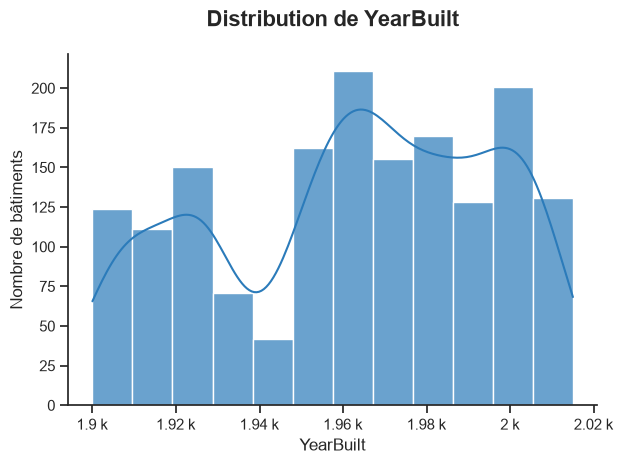

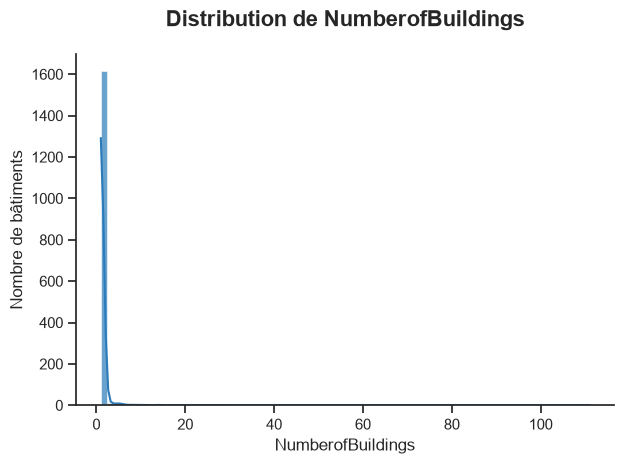

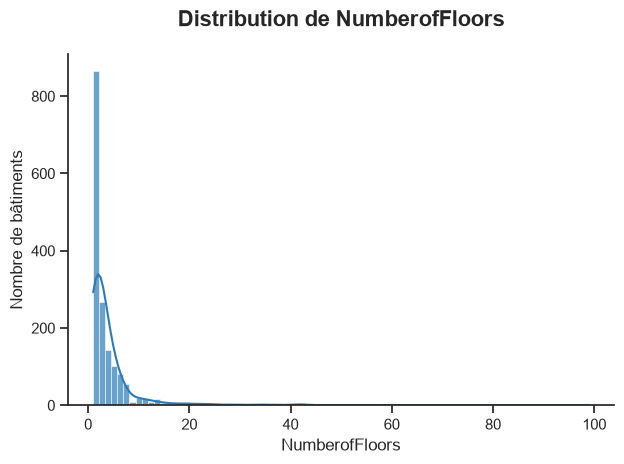

In [ ]:
# Style général
sns.set_theme(style="ticks")

for col in colnum:

    # Création de l'histogramme
    ax = sns.histplot(
        data=df,
        x=col,
        log_scale=False,
        color="#2b7bba",  # Un bleu plus pro que le bleu par défaut
        alpha=0.7,  # Légère transparence
        edgecolor="white",  # Séparation nette entre les barres
        kde=True,  # Ajoute une courbe d'estimation de densité
    )

    plt.title("Distribution de " + col, fontsize=16, pad=20, fontweight="bold")
    plt.xlabel(col, fontsize=12)
    plt.ylabel("Nombre de bâtiments", fontsize=12)

    # 2. Formatage des axes (Transformation des 10^x en nombres lisibles)
    ax.xaxis.set_major_formatter(ticker.EngFormatter())

    # Nettoyage des bordures
    sns.despine()

    plt.tight_layout()
    plt.show()

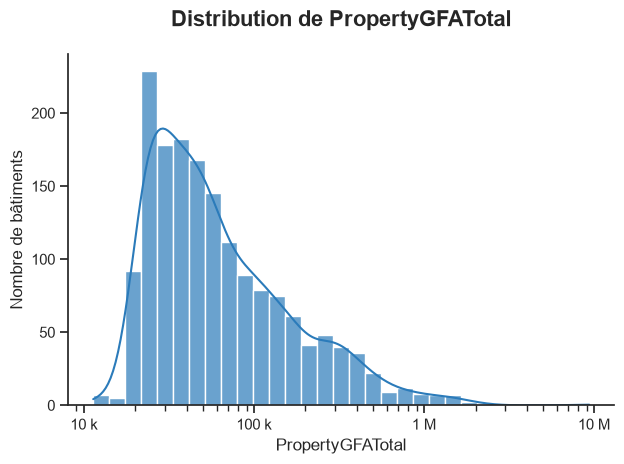

c:\Users\Kevin\projects\OC_P13\.venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


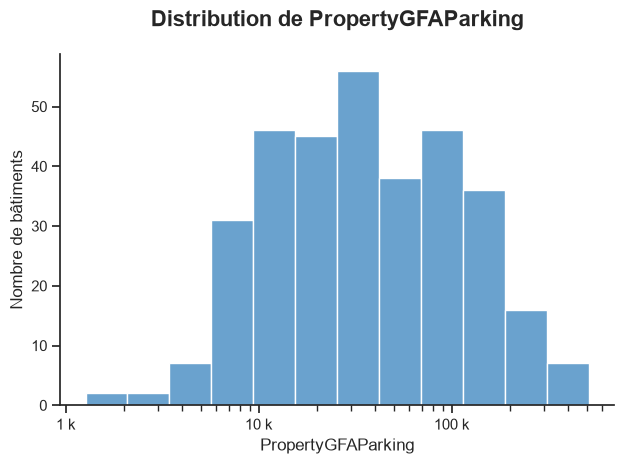

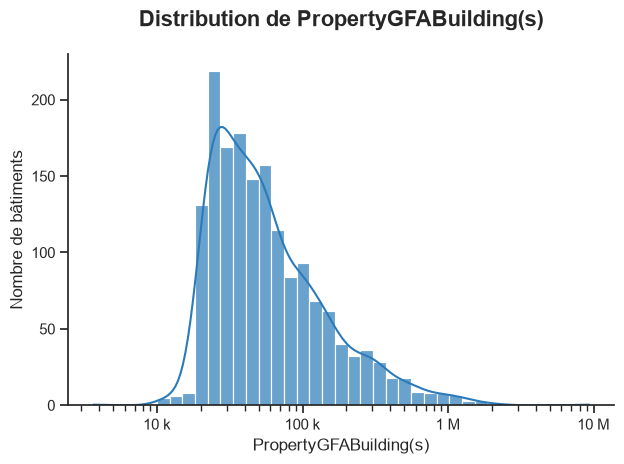

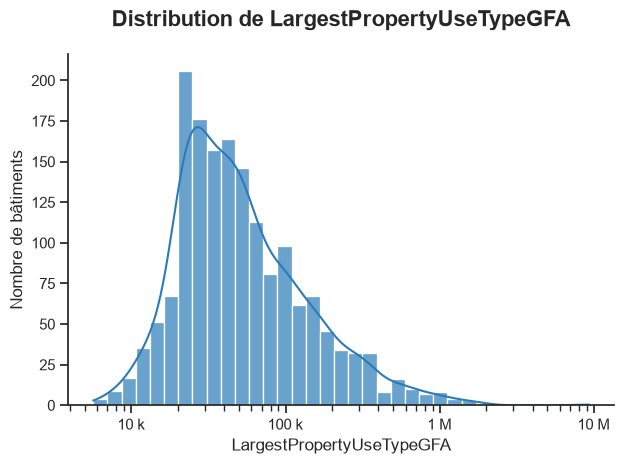

c:\Users\Kevin\projects\OC_P13\.venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


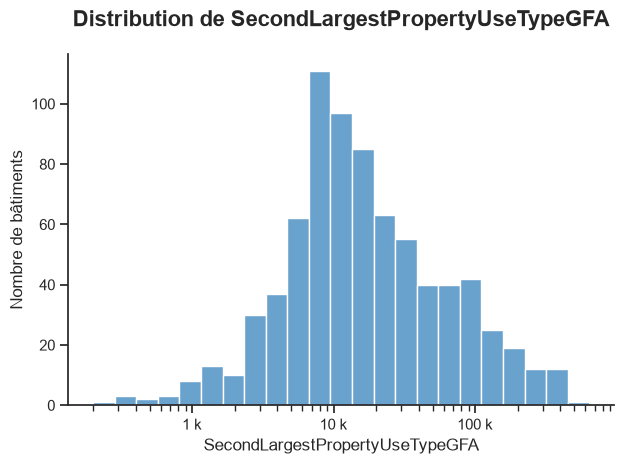

c:\Users\Kevin\projects\OC_P13\.venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


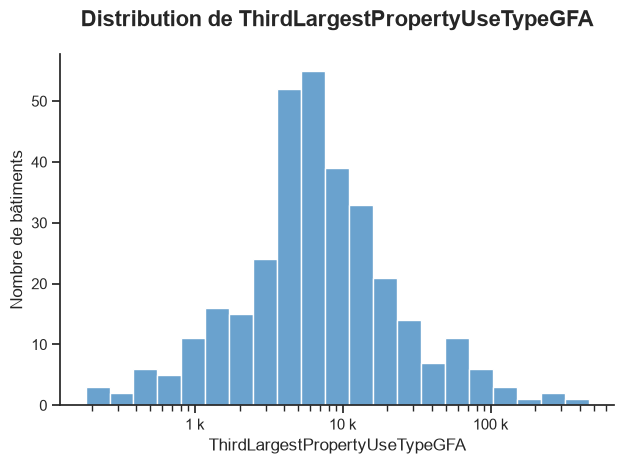

c:\Users\Kevin\projects\OC_P13\.venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


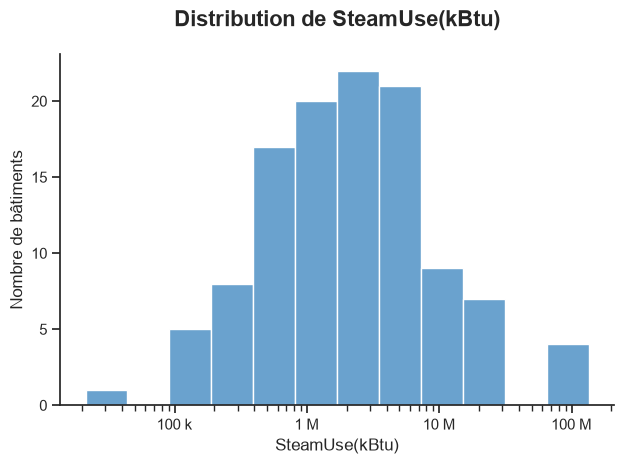

c:\Users\Kevin\projects\OC_P13\.venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


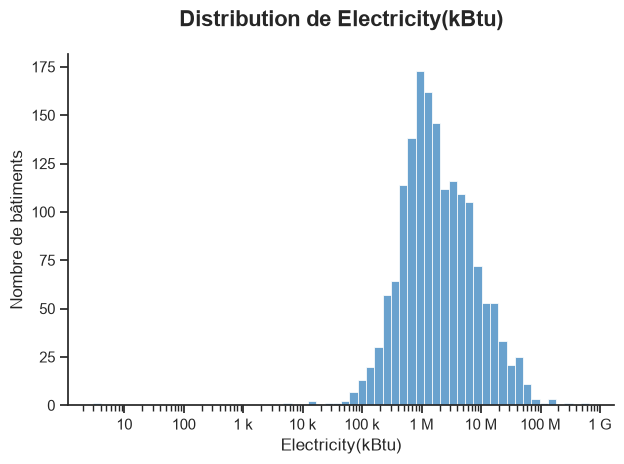

c:\Users\Kevin\projects\OC_P13\.venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


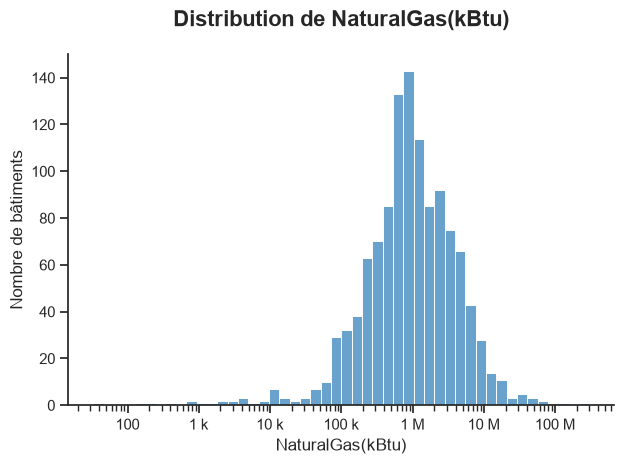

In [ ]:
# Style général
sns.set_theme(style="ticks")

for col in colnumlog:
    # Création de l'histogramme
    ax = sns.histplot(
        data=df,
        x=col,
        log_scale=True,
        color="#2b7bba",  # Un bleu plus pro que le bleu par défaut
        alpha=0.7,  # Légère transparence
        edgecolor="white",  # Séparation nette entre les barres
        kde=True,  # Ajoute une courbe d'estimation de densité
    )

    plt.title("Distribution de " + col, fontsize=16, pad=20, fontweight="bold")
    plt.xlabel(col, fontsize=12)
    plt.ylabel("Nombre de bâtiments", fontsize=12)

    # 2. Formatage des axes (Transformation des 10^x en nombres lisibles)
    ax.xaxis.set_major_formatter(ticker.EngFormatter())

    # Nettoyage des bordures
    sns.despine()

    plt.tight_layout()
    plt.show()

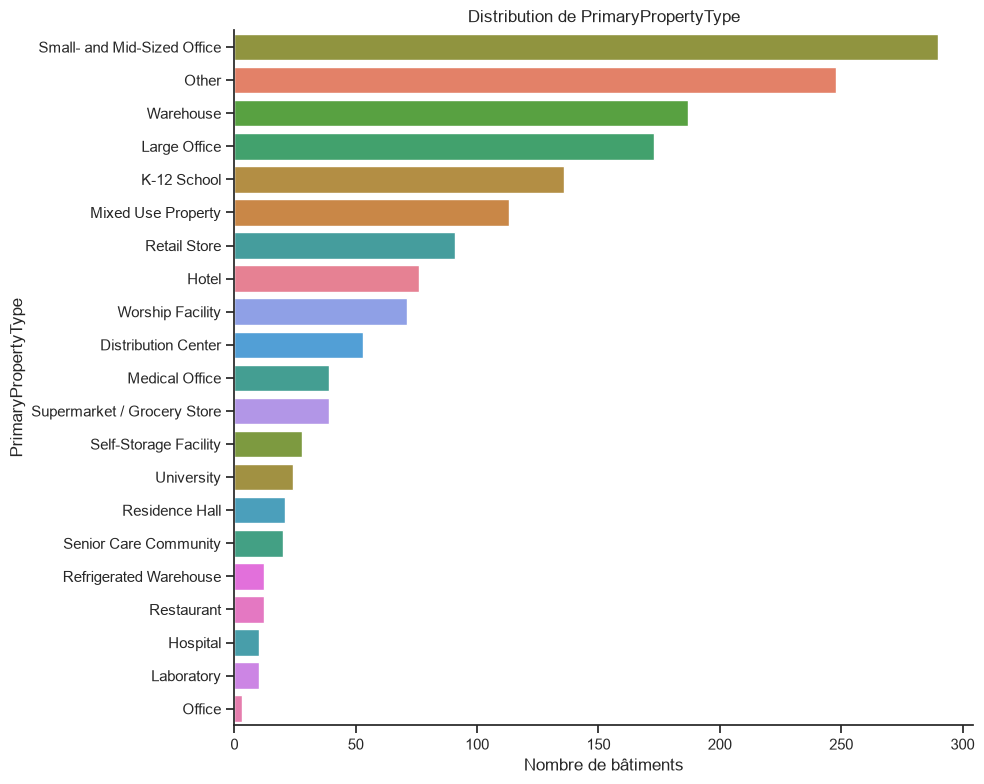

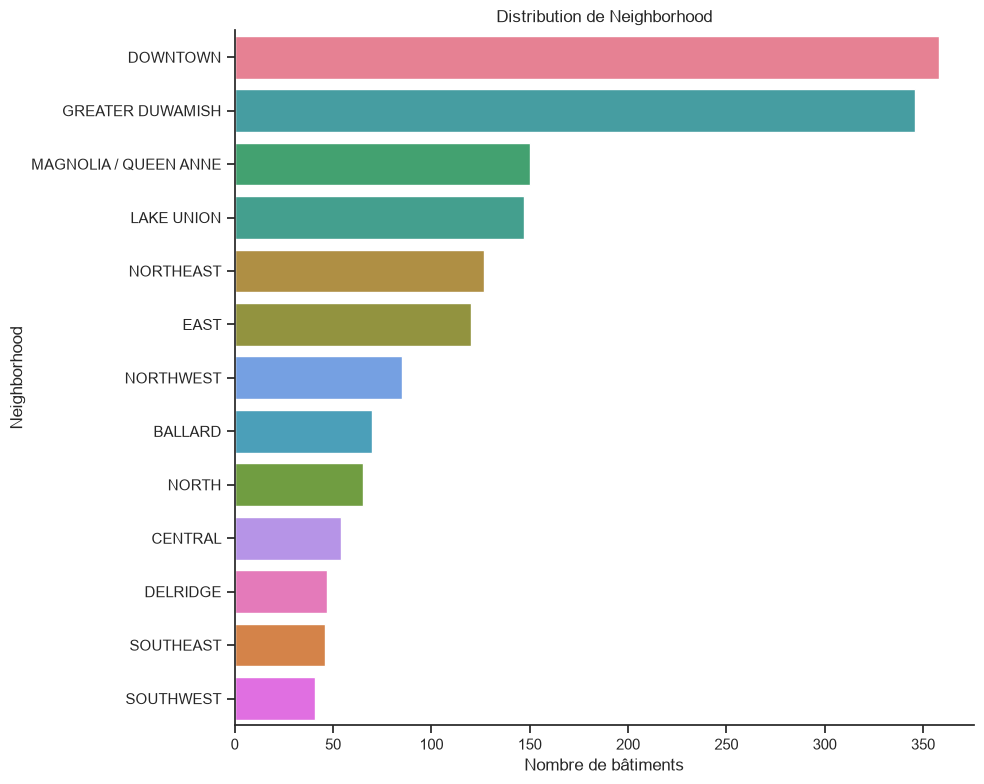

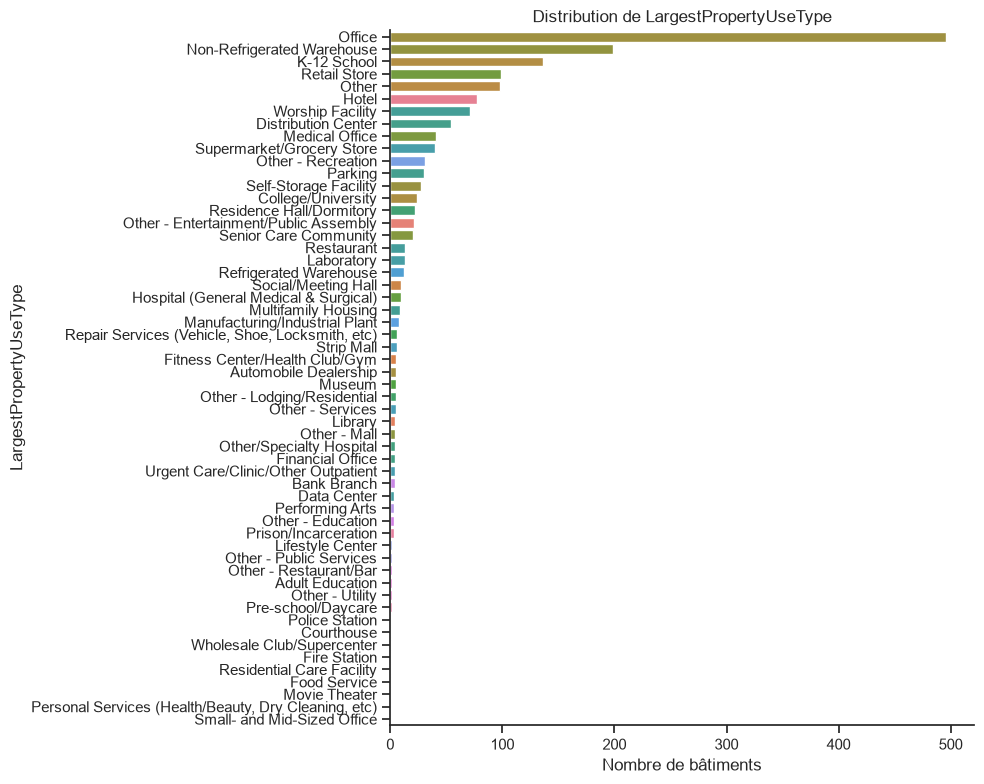

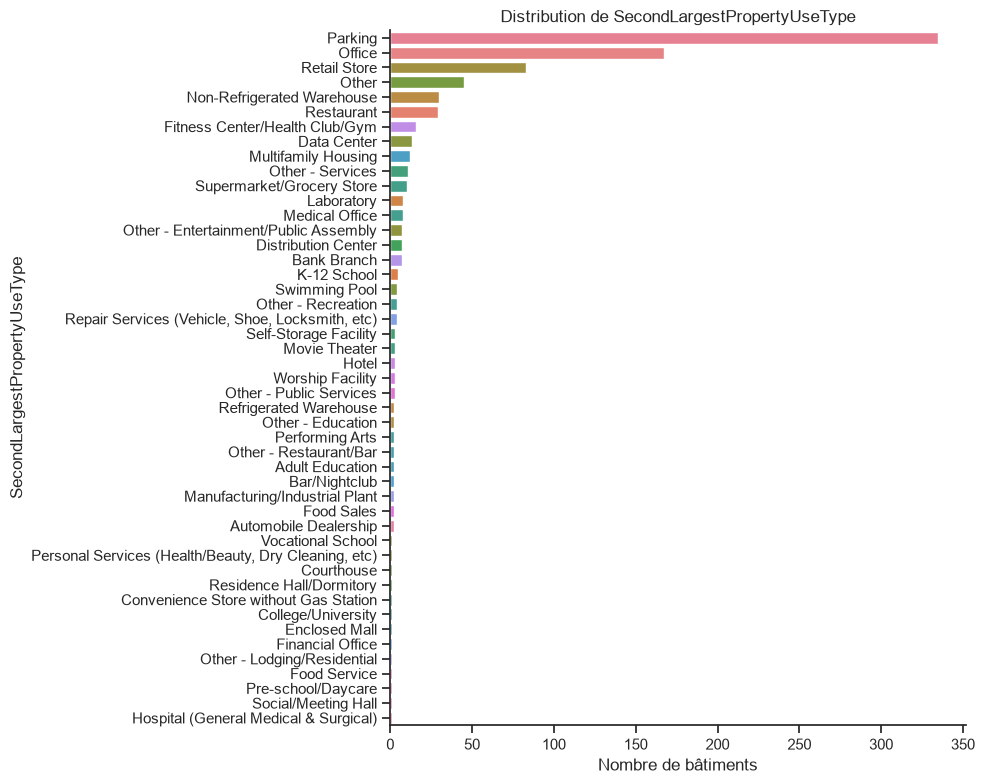

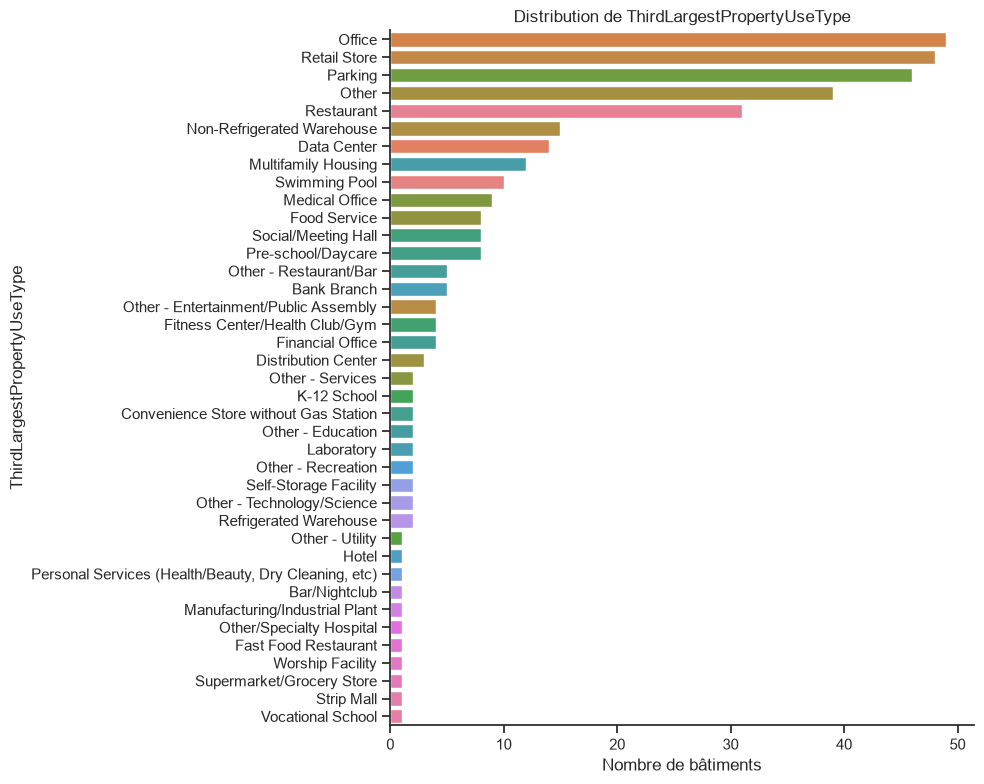

In [ ]:
for col in colcat:
    # On calcule l'ordre pour que le graphique soit trié
    order = df[col].value_counts().index
    plt.figure(figsize=(10, 8))
    ax = sns.countplot(data=df, y=col, order=order, hue=col, legend=False)
    plt.title("Distribution de " + col)
    plt.xlabel("Nombre de bâtiments")
    plt.ylabel(col)
    sns.despine()
    ax.xaxis.set_major_formatter(ticker.EngFormatter())

    plt.tight_layout()
    plt.show()

## Observations graphiques et visualisations des cibles

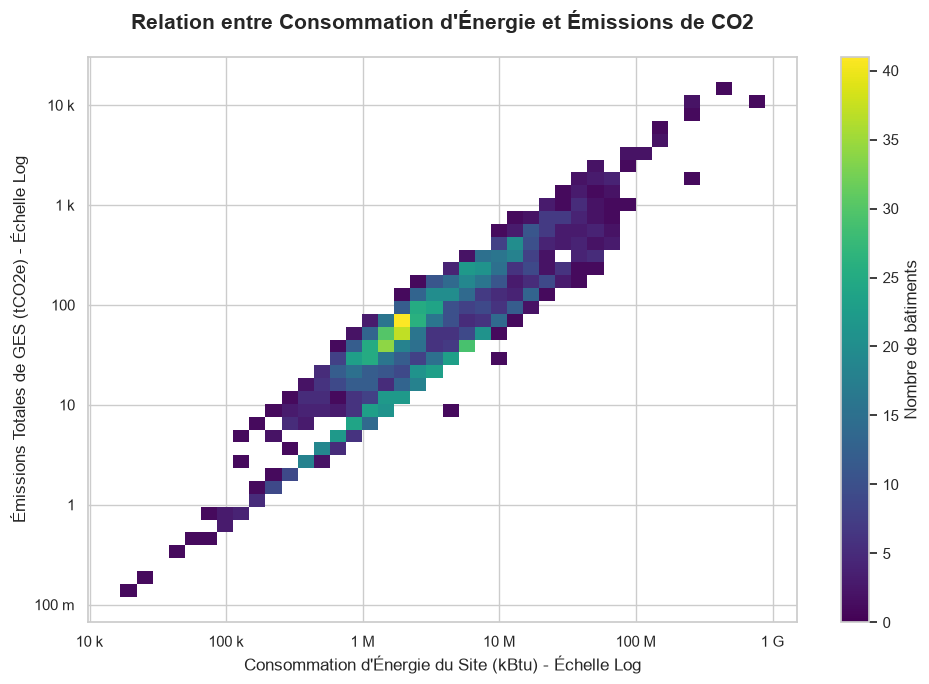

In [ ]:
# On définit un style plus propre (fond blanc avec grille légère)
sns.set_theme(style="whitegrid")

# Création de la figure avec une taille optimale
plt.figure(figsize=(10, 7))

# Création du histplot
# Note : cbar=True active la barre de couleur, pas besoin de lui passer 'viridis'
ax = sns.histplot(
    data=df,
    x="SiteEnergyUse(kBtu)",
    y="TotalGHGEmissions",
    log_scale=True,
    cmap="viridis",
    bins=40,  # Augmenté pour plus de précision
    cbar=True,
    cbar_kws={"label": "Nombre de bâtiments"},  # Label sur la barre de couleur
)

# --- AMÉLIORATIONS PROFESSIONNELLES ---

# 1. Titres et labels explicites
plt.title(
    "Relation entre Consommation d'Énergie et Émissions de CO2",
    fontsize=15,
    pad=20,
    fontweight="bold",
)
plt.xlabel("Consommation d'Énergie du Site (kBtu) - Échelle Log", fontsize=12)
plt.ylabel("Émissions Totales de GES (tCO2e) - Échelle Log", fontsize=12)

# 2. Améliorer les graduations des axes (Ticks)
# Pour que l'utilisateur lise "10k" au lieu de "10^4" ou "10000"
ax.xaxis.set_major_formatter(ticker.EngFormatter())
ax.yaxis.set_major_formatter(ticker.EngFormatter())

plt.tight_layout()
plt.show()

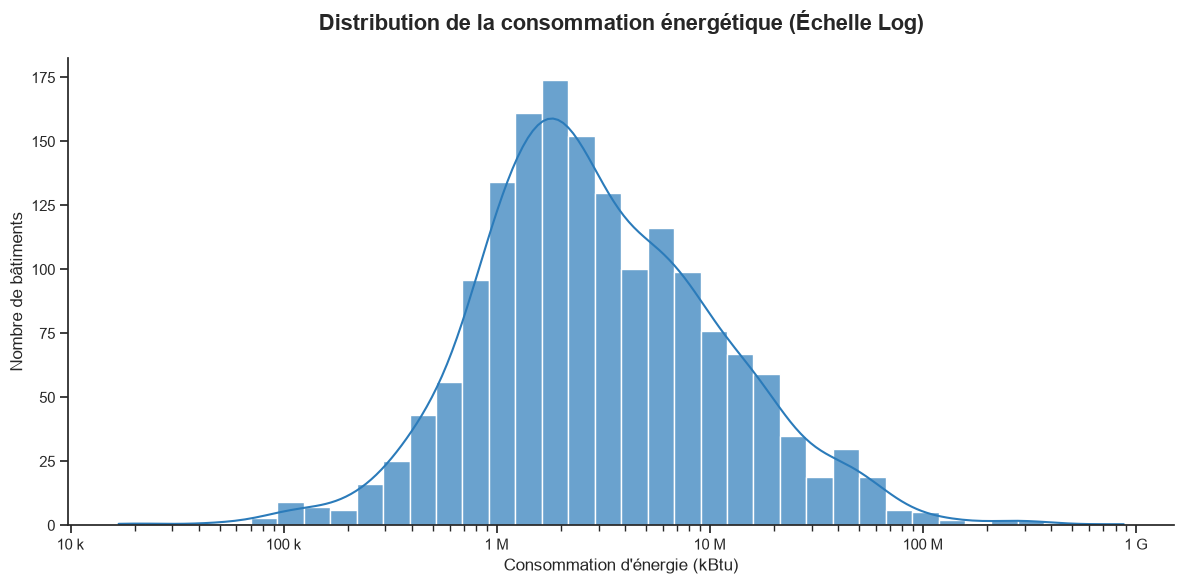

In [ ]:
# Style général
sns.set_theme(style="ticks")

plt.figure(figsize=(12, 6))

# Création de l'histogramme
ax = sns.histplot(
    data=df,
    x="SiteEnergyUse(kBtu)",
    log_scale=True,
    color="#2b7bba",  # Un bleu plus pro que le bleu par défaut
    alpha=0.7,  # Légère transparence
    edgecolor="white",  # Séparation nette entre les barres
    kde=True,  # Ajoute une courbe d'estimation de densité
)

# --- PERSONNALISATION AVANCÉE ---

# 1. Labels et Titre
plt.title(
    "Distribution de la consommation énergétique (Échelle Log)",
    fontsize=16,
    pad=20,
    fontweight="bold",
)
plt.xlabel("Consommation d'énergie (kBtu)", fontsize=12)
plt.ylabel("Nombre de bâtiments", fontsize=12)

# 2. Formatage des axes (Transformation des 10^x en nombres lisibles)
ax.xaxis.set_major_formatter(ticker.EngFormatter())


# Nettoyage des bordures
sns.despine()

plt.tight_layout()
plt.show()

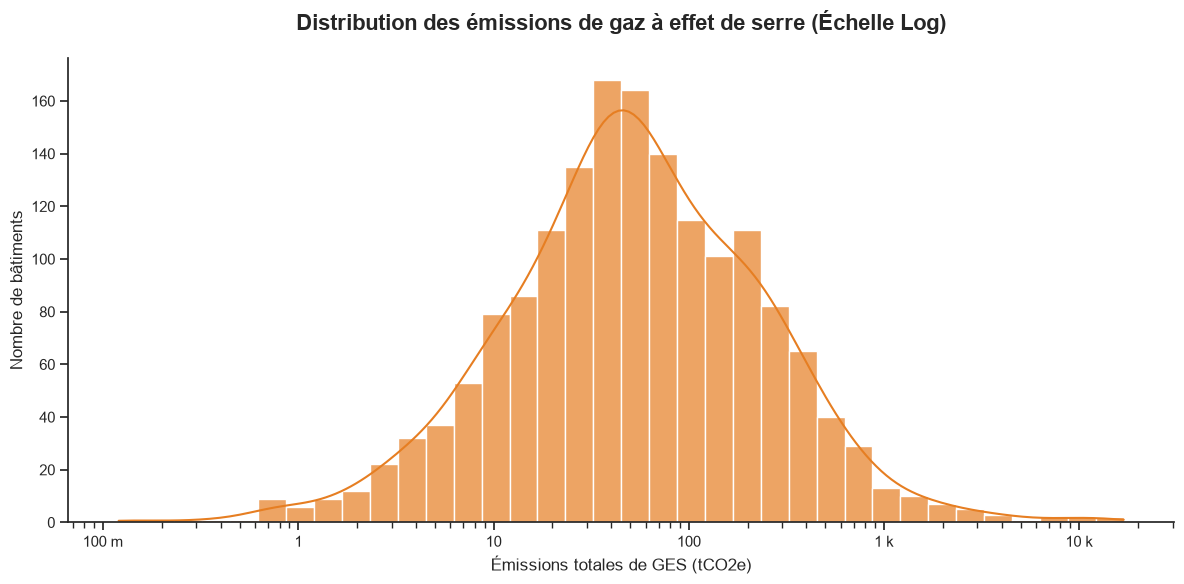

In [ ]:
# On garde exactement le même thème
sns.set_theme(style="ticks")

plt.figure(figsize=(12, 6))

# Création de l'histogramme (Style raccord avec le précédent)
ax = sns.histplot(
    data=df,
    x="TotalGHGEmissions",
    log_scale=True,
    color="#e67e22",  # Une couleur distincte (orange/terre) mais de même intensité
    alpha=0.7,
    edgecolor="white",
    kde=True,
)

# --- PERSONNALISATION (IDENTIQUE AU PRÉCÉDENT) ---

# 1. Labels et Titre
plt.title(
    "Distribution des émissions de gaz à effet de serre (Échelle Log)",
    fontsize=16,
    pad=20,
    fontweight="bold",
)
plt.xlabel("Émissions totales de GES (tCO2e)", fontsize=12)
plt.ylabel("Nombre de bâtiments", fontsize=12)

# 2. Formatage des axes (Transformation lisible)
ax.xaxis.set_major_formatter(ticker.EngFormatter())


# Nettoyage des bordures
sns.despine()

plt.tight_layout()
plt.show()

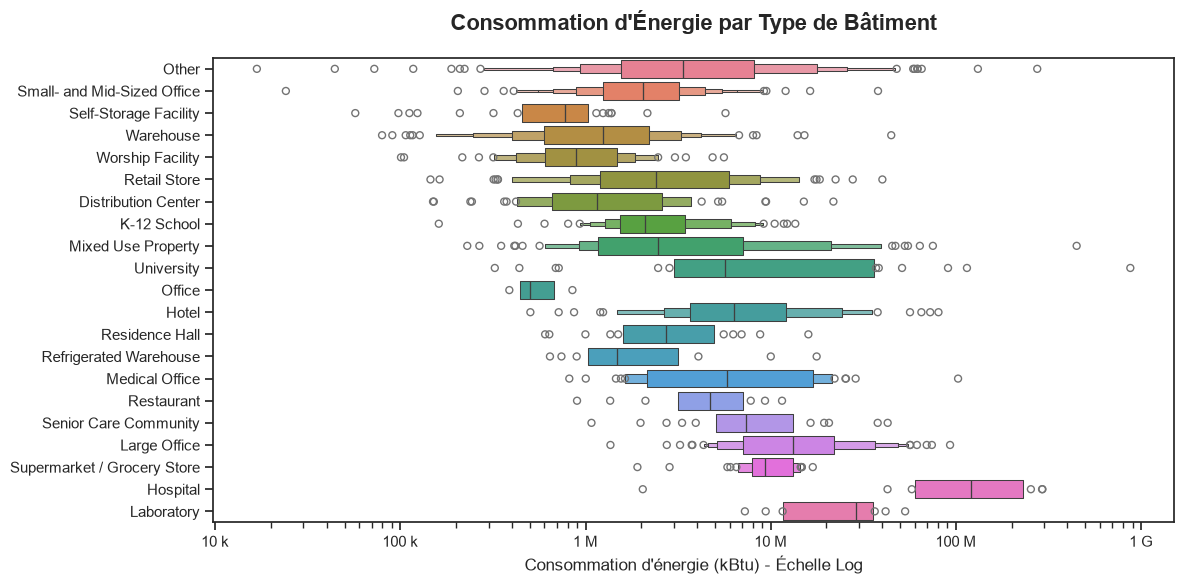

In [ ]:
# On reste sur le style "ticks" pour la cohérence
sns.set_theme(style="ticks")

# On agrandit un peu la hauteur (8 au lieu de 6) car les labels verticaux
# de 'PrimaryPropertyType' prennent souvent de la place
plt.figure(figsize=(12, 6))

# Création du boxenplot
ax = sns.boxenplot(
    data=df.sort_values(
        "SiteEnergyUse(kBtu)", ascending=True
    ),  # Trié pour plus de clarté
    y="PrimaryPropertyType",
    x="SiteEnergyUse(kBtu)",
    orient="h",
    showfliers=True,
    hue="PrimaryPropertyType",
    legend=False,
)

# --- FINITIONS PROFESSIONNELLES ---

# 1. Échelle Log et Formatage
plt.xscale("log")
ax.xaxis.set_major_formatter(ticker.EngFormatter())

# 2. Titres et Labels
plt.title(
    "Consommation d'Énergie par Type de Bâtiment",
    fontsize=16,
    pad=20,
    fontweight="bold",
)
plt.xlabel("Consommation d'énergie (kBtu) - Échelle Log", fontsize=12)
plt.ylabel("")  # On retire le label Y car les noms des catégories suffisent

plt.tight_layout()
plt.show()

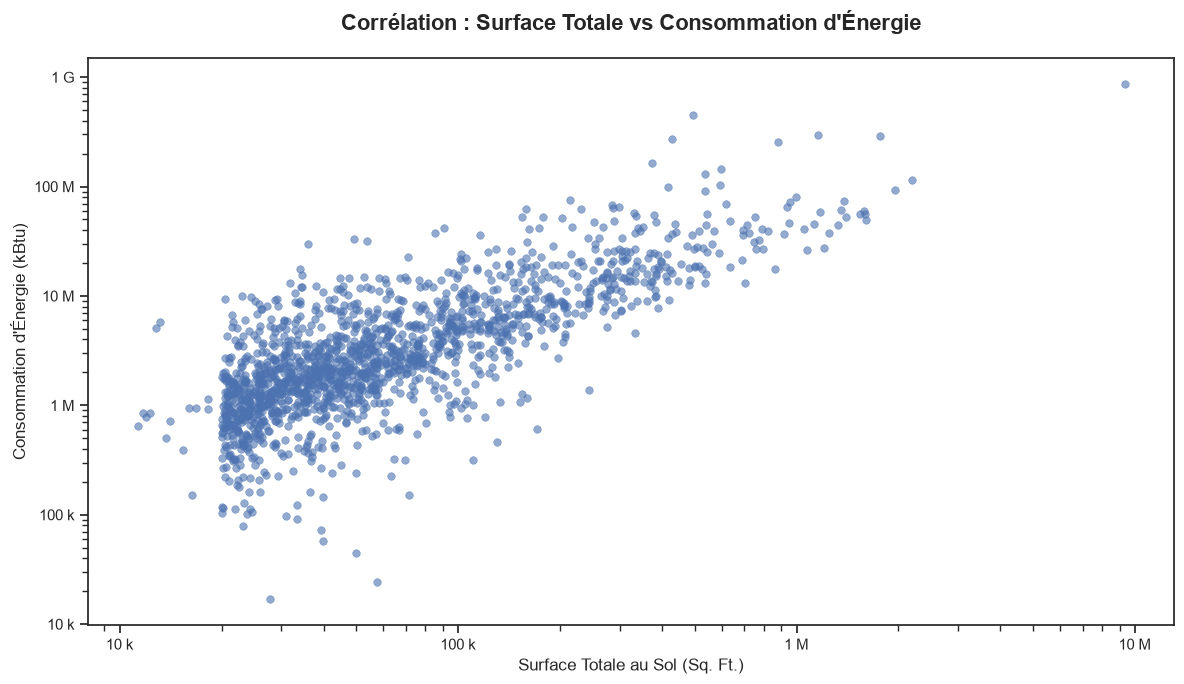

In [ ]:
# On reste sur le thème "ticks" pour la cohérence
sns.set_theme(style="ticks")

plt.figure(figsize=(12, 7))

# Scatterplot amélioré
ax = sns.scatterplot(
    data=df,
    x="PropertyGFATotal",
    y="SiteEnergyUse(kBtu)",
    alpha=0.6,  # Transparence pour voir les points superposés
    edgecolor=None,  # Retire le bord blanc des points pour plus de légèreté
    s=30,  # Taille des points
)

# --- FINITIONS PROFESSIONNELLES ---

# 1. Échelles Log et Formatage Ingénieur (Indispensable ici)
plt.xscale("log")
plt.yscale("log")
ax.xaxis.set_major_formatter(ticker.EngFormatter())
ax.yaxis.set_major_formatter(ticker.EngFormatter())

# 2. Titres et Labels
plt.title(
    "Corrélation : Surface Totale vs Consommation d'Énergie",
    fontsize=16,
    pad=20,
    fontweight="bold",
)
plt.xlabel("Surface Totale au Sol (Sq. Ft.)", fontsize=12)
plt.ylabel("Consommation d'Énergie (kBtu)", fontsize=12)

plt.tight_layout()
plt.show()

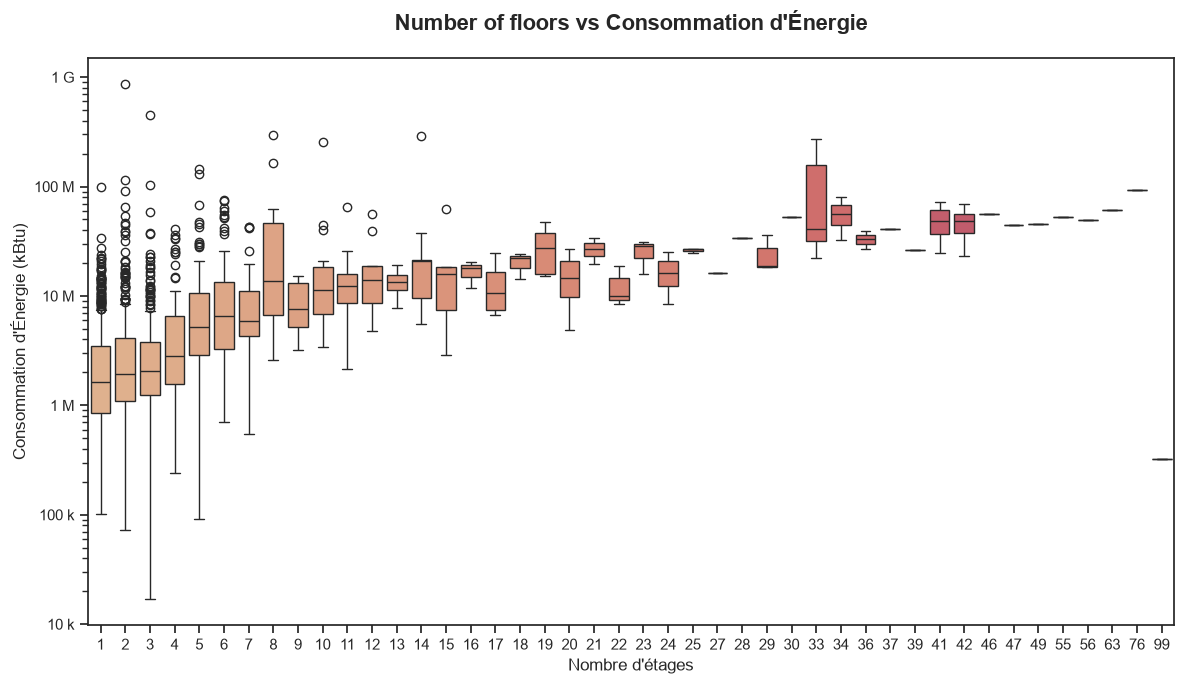

In [ ]:
sns.set_theme(style="ticks")

plt.figure(figsize=(12, 7))

ax = sns.boxplot(
    data=df,
    x="NumberofFloors",
    y="SiteEnergyUse(kBtu)",
    showfliers=True,
    hue="NumberofFloors",
    palette="flare",
    legend=False,
)
plt.yscale("log")
ax.yaxis.set_major_formatter(ticker.EngFormatter())
plt.title(
    "Number of floors vs Consommation d'Énergie", fontsize=16, pad=20, fontweight="bold"
)
plt.xlabel("Nombre d'étages", fontsize=12)
plt.ylabel("Consommation d'Énergie (kBtu)", fontsize=12)
plt.tight_layout()
plt.show()

### Qualité de donnée déclarée par la source

La Ville publie deux colonnes que P3 n'avait pas retenues : `Outlier`, où elle
signale elle-même les valeurs suspectes, et `ComplianceStatus`, qui indique si la
déclaration repose sur des relevés réels.

Elles sont conservées dans `dfclean.csv` comme **métadonnées** — elles ne
deviendront jamais des variables du modèle, puisqu'elles n'existent pas pour un
bâtiment non encore relevé. Elles servent à décider quels exemples sont dignes de
confiance pour l'entraînement.

Attention à ne pas confondre avec les très gros consommateurs : le campus
universitaire de 9,3 M sq ft à 874 M kBtu n'est pas une anomalie, il est déclaré
conforme et non signalé. Ce sont des bâtiments réels, que la Ville doit justement
savoir estimer.

In [ ]:
print("--- Outlier (signale par la Ville) ---")
print(df["Outlier"].fillna("(non signale)").value_counts().to_string())
print()
print("--- ComplianceStatus ---")
print(df["ComplianceStatus"].fillna("(vide)").value_counts().to_string())

suspect = df["Outlier"].notna() | (df["ComplianceStatus"] != "Compliant")
print()
print(f"batiments portant au moins un signalement : {suspect.sum()} "
      f"({suspect.mean():.1%} du jeu)")

# Do the flagged ones look different? Intensity is the fair comparison here.
intensite = df["SiteEnergyUse(kBtu)"] / df["PropertyGFATotal"]
print()
print(pd.DataFrame({
    "n": [(~suspect).sum(), suspect.sum()],
    "intensite mediane": [intensite[~suspect].median(), intensite[suspect].median()],
    "surface mediane": [df.loc[~suspect, "PropertyGFATotal"].median(),
                        df.loc[suspect, "PropertyGFATotal"].median()],
}, index=["non signales", "signales"]).round(1))

## Export pour la suite du pipeline

`dfclean.csv` est le jeu **nettoyé mais non transformé** : le feature
engineering (encodages, ratios, âge, log des cibles) est fait en aval par
`src/features.py`, de manière à être rejoué à l'identique à l'inférence.

In [ ]:
df

,OSEBuildingID,PrimaryPropertyType,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,SiteEnergyUse(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions
0,1,Hotel,DOWNTOWN,1927,1.0,12,88434,0,88434,Hotel,Hotel,88434.0,NaN,NaN,NaN,NaN,7.226362e+06,2003882.00,3.946027e+06,1.276453e+06,249.98
1,2,Hotel,DOWNTOWN,1996,1.0,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880.0,Parking,15064.0,Restaurant,4622.0,8.387933e+06,0.00,3.242851e+06,5.145082e+06,295.86
2,3,Hotel,DOWNTOWN,1969,1.0,41,956110,196718,759392,Hotel,Hotel,756493.0,NaN,NaN,NaN,NaN,7.258702e+07,21566554.00,4.952666e+07,1.493800e+06,2089.28
3,5,Hotel,DOWNTOWN,1926,1.0,10,61320,0,61320,Hotel,Hotel,61320.0,NaN,NaN,NaN,NaN,6.794584e+06,2214446.25,2.768924e+06,1.811213e+06,286.43
4,8,Hotel,DOWNTOWN,1980,1.0,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,123445.0,Parking,68009.0,Swimming Pool,0.0,1.417261e+07,0.00,5.368607e+06,8.803998e+06,505.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1651,50222,Office,GREATER DUWAMISH,1990,1.0,1,12294,0,12294,Office,Office,12294.0,NaN,NaN,NaN,NaN,8.497457e+05,0.00,5.242709e+05,3.254750e+05,20.94
1652,50223,Other,DOWNTOWN,2004,1.0,1,16000,0,16000,Other - Recreation,Other - Recreation,16000.0,NaN,NaN,NaN,NaN,9.502762e+05,0.00,3.965461e+05,5.537300e+05,32.17
1653,50224,Other,MAGNOLIA / QUEEN ANNE,1974,1.0,1,13157,0,13157,"Fitness Center/Health Club/Gym, Other - Recrea...",Other - Recreation,7583.0,Fitness Center/Health Club/Gym,5574.0,Swimming Pool,0.0,5.765898e+06,0.00,1.792159e+06,3.973739e+06,223.54
1654,50225,Mixed Use Property,GREATER DUWAMISH,1989,1.0,1,14101,0,14101,"Fitness Center/Health Club/Gym, Food Service, ...",Other - Recreation,6601.0,Fitness Center/Health Club/Gym,6501.0,Pre-school/Daycare,484.0,7.194712e+05,0.00,3.488702e+05,3.706010e+05,22.11


In [ ]:
# Sanity checks before export - these must hold for the downstream pipeline
assert df["OSEBuildingID"].is_unique, "OSEBuildingID doit être unique"
assert df["SiteEnergyUse(kBtu)"].gt(0).all(), "Cible énergie : valeurs non strictement positives"
assert df["TotalGHGEmissions"].gt(0).all(), "Cible émissions : valeurs non strictement positives"

print("Shape :", df.shape)
print("\nValeurs manquantes restantes :")
print(df.isna().sum()[df.isna().sum() > 0])

out = DATA_DIR / "dfclean.csv"
df.to_csv(out, index=False)
print(f"\nExporté -> {out}")

Shape : (1656, 21)

Valeurs manquantes restantes :
LargestPropertyUseType                1
LargestPropertyUseTypeGFA             1
SecondLargestPropertyUseType        805
SecondLargestPropertyUseTypeGFA     805
ThirdLargestPropertyUseType        1305
ThirdLargestPropertyUseTypeGFA     1305
dtype: int64

Exporté -> c:\Users\Kevin\projects\OC_P13\data\dfclean.csv
